# CSCI-333 Final Project
By Travis Webber

## Introduction

The data analyses in this notebook is performed on the "Digital Lifestyle Benchmark" dataset found at https://www.kaggle.com/datasets/tarekmasryo/digital-health-and-mental-wellness

The goal of working with this dataset is to use data analyses and machine learning tools to determine correlations between digital habits and mental wellbeing. I will be determining which aspects of digital use are most significant in impacting mental health and testing different machine learning models to predict when these habits result in higher risk of negative mental health.

This dataset consists of synthetic entries that are designed to reflect the patterns and trends found in real-world psychological research.

Disclaimer: Most matplotlib and seaborn visualization code has been generated by chatgpt with personal adjustments.

## Getting started

To start off, I want to import all of the libraries I know will be necessary for initial data analyses and visualization. For initial machine learning tasks, I am also importing different models that we learned in class along with evaluation tools. I have also found other similar models to test from the same libraries.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('Data.csv')

### Initial Inspection

Before getting into EDA or preprocessing for model training, I want to know how many entries there are in the dataset, the number of features, and the data types of those features. The describe function will also give a good idea of the value ranges for each numeric feature.

In [3]:
print(df.shape)

(3500, 24)


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        3500 non-null   int64  
 1   age                       3500 non-null   int64  
 2   gender                    3500 non-null   object 
 3   region                    3500 non-null   object 
 4   income_level              3500 non-null   object 
 5   education_level           3500 non-null   object 
 6   daily_role                3500 non-null   object 
 7   device_hours_per_day      3500 non-null   float64
 8   phone_unlocks             3500 non-null   int64  
 9   notifications_per_day     3500 non-null   int64  
 10  social_media_mins         3500 non-null   int64  
 11  study_mins                3500 non-null   int64  
 12  physical_activity_days    3500 non-null   float64
 13  sleep_hours               3500 non-null   float64
 14  sleep_qu

The dataset has 3500 entries and 24 different features. This is a reasonably sized dataset that should have enough entries for proper analyses while remaining managable. The variety of features allows for deeper investigation into their relationships and significance. I can see that the id column will be able to be dropped since the data will already be indexed within the data frame.

Most of the data types are numeric which may require scaling for more accurate analysis. There are also 6 object features that will need to be encoded.

In [5]:
print(df.describe())

                id          age  device_hours_per_day  phone_unlocks  \
count  3500.000000  3500.000000           3500.000000    3500.000000   
mean   1750.500000    28.078571              7.317677     147.107429   
std    1010.507298     9.352385              3.239838      67.770656   
min       1.000000    13.000000              0.280000       9.000000   
25%     875.750000    21.000000              4.867500      96.000000   
50%    1750.500000    27.000000              6.760000     136.000000   
75%    2625.250000    34.000000              9.152500     187.000000   
max    3500.000000    50.000000             17.160000     374.000000   

       notifications_per_day  social_media_mins   study_mins  \
count            3500.000000        3500.000000  3500.000000   
mean              335.117143         159.362857   108.116571   
std               239.678612         132.748048    79.796273   
min                22.000000           0.000000     0.000000   
25%               170.000000   

This output shows that some features like notifications_per_day, social_media_mins, and study_mins may require scaling for better analyses.

In [6]:
print(df.isnull().sum())

id                          0
age                         0
gender                      0
region                      0
income_level                0
education_level             0
daily_role                  0
device_hours_per_day        0
phone_unlocks               0
notifications_per_day       0
social_media_mins           0
study_mins                  0
physical_activity_days      0
sleep_hours                 0
sleep_quality               0
anxiety_score               0
depression_score            0
stress_level                0
happiness_score             0
focus_score                 0
high_risk_flag              0
device_type                 0
productivity_score          0
digital_dependence_score    0
dtype: int64


There are no missing values to handle.

In [7]:
df.head()

,id,age,gender,region,income_level,education_level,daily_role,device_hours_per_day,phone_unlocks,notifications_per_day,...,sleep_quality,anxiety_score,depression_score,stress_level,happiness_score,focus_score,high_risk_flag,device_type,productivity_score,digital_dependence_score
0,1,40,Female,Asia,High,High School,Part-time/Shift,3.54,45,561,...,3.353627,9.926651,5.0,6.593289,8.0,23.0,0,Android,70.000000,25.700000
1,2,27,Male,Africa,Lower-Mid,Master,Full-time Employee,5.65,100,393,...,2.908147,4.000000,4.0,4.126926,8.1,35.0,0,Laptop,64.000000,30.100000
2,3,31,Male,North America,Lower-Mid,Bachelor,Full-time Employee,8.87,181,231,...,2.889213,4.000000,8.0,1.429139,7.6,15.0,0,Android,65.299301,40.600000
3,4,41,Female,Middle East,Low,Master,Caregiver/Home,4.05,94,268,...,3.097488,7.093357,9.0,4.995512,7.8,28.0,1,Tablet,80.000000,36.684152
4,5,26,Female,Europe,Lower-Mid,Bachelor,Full-time Employee,13.07,199,91,...,2.786098,7.028125,15.0,9.448757,4.2,70.0,1,Android,65.299301,48.400000


## Separating Analyses and Model Training Dataframes

Now that the structure and contents of the data have been laid out, I want to have two different dataframes that are adjusted to fit the needs of EDA and training ML models. For data analysis I want to keep the original dataset in its original form so that queries and visualization is more interpretable. A separate dataframe will be created for the purposes of training various models. This dataframe will go through various forms of preprocessing and tuning to fit the needs of model training.

In [8]:
# Both frames will drop the 'id' feature as it has no significance in EDA or training
df_eda = df.copy().drop('id', axis=1)
df_training = df_eda.copy()

In [9]:
print(df_eda.shape)
df_eda.head()

(3500, 23)


,age,gender,region,income_level,education_level,daily_role,device_hours_per_day,phone_unlocks,notifications_per_day,social_media_mins,...,sleep_quality,anxiety_score,depression_score,stress_level,happiness_score,focus_score,high_risk_flag,device_type,productivity_score,digital_dependence_score
0,40,Female,Asia,High,High School,Part-time/Shift,3.54,45,561,98,...,3.353627,9.926651,5.0,6.593289,8.0,23.0,0,Android,70.000000,25.700000
1,27,Male,Africa,Lower-Mid,Master,Full-time Employee,5.65,100,393,174,...,2.908147,4.000000,4.0,4.126926,8.1,35.0,0,Laptop,64.000000,30.100000
2,31,Male,North America,Lower-Mid,Bachelor,Full-time Employee,8.87,181,231,595,...,2.889213,4.000000,8.0,1.429139,7.6,15.0,0,Android,65.299301,40.600000
3,41,Female,Middle East,Low,Master,Caregiver/Home,4.05,94,268,18,...,3.097488,7.093357,9.0,4.995512,7.8,28.0,1,Tablet,80.000000,36.684152
4,26,Female,Europe,Lower-Mid,Bachelor,Full-time Employee,13.07,199,91,147,...,2.786098,7.028125,15.0,9.448757,4.2,70.0,1,Android,65.299301,48.400000


In [10]:
print(df_training.shape)
df_training.head()

(3500, 23)


,age,gender,region,income_level,education_level,daily_role,device_hours_per_day,phone_unlocks,notifications_per_day,social_media_mins,...,sleep_quality,anxiety_score,depression_score,stress_level,happiness_score,focus_score,high_risk_flag,device_type,productivity_score,digital_dependence_score
0,40,Female,Asia,High,High School,Part-time/Shift,3.54,45,561,98,...,3.353627,9.926651,5.0,6.593289,8.0,23.0,0,Android,70.000000,25.700000
1,27,Male,Africa,Lower-Mid,Master,Full-time Employee,5.65,100,393,174,...,2.908147,4.000000,4.0,4.126926,8.1,35.0,0,Laptop,64.000000,30.100000
2,31,Male,North America,Lower-Mid,Bachelor,Full-time Employee,8.87,181,231,595,...,2.889213,4.000000,8.0,1.429139,7.6,15.0,0,Android,65.299301,40.600000
3,41,Female,Middle East,Low,Master,Caregiver/Home,4.05,94,268,18,...,3.097488,7.093357,9.0,4.995512,7.8,28.0,1,Tablet,80.000000,36.684152
4,26,Female,Europe,Lower-Mid,Bachelor,Full-time Employee,13.07,199,91,147,...,2.786098,7.028125,15.0,9.448757,4.2,70.0,1,Android,65.299301,48.400000


## Preprocessing

With two separate dataframes, I want to perform some general preprocessing on both.

### Label Encoding

#### EDA Frame

In [11]:
for col in df_eda.select_dtypes(include='object').columns:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: gender
['Female' 'Male']

Column: region
['Asia' 'Africa' 'North America' 'Middle East' 'Europe' 'South America']

Column: income_level
['High' 'Lower-Mid' 'Low' 'Upper-Mid']

Column: education_level
['High School' 'Master' 'Bachelor' 'PhD']

Column: daily_role
['Part-time/Shift' 'Full-time Employee' 'Caregiver/Home'
 'Unemployed_Looking' 'Student']

Column: device_type
['Android' 'Laptop' 'Tablet' 'iPhone']


Since income_level and education_level are the only features with inherent order, I will add columns to help represent that. This will add some further analyses capabilities.

In [12]:
# Ordered
income_map = {
    'Low': 0,
    'Lower-Mid': 1,
    'Upper-Mid': 2,
    'High': 3
}
education_map = {
    'High School': 0,
    'Bachelor': 1,
    'Master': 2,
    'PhD': 3
}

In [13]:
df_eda['income_ord'] = df_eda['income_level'].map(income_map)
df_eda['education_ord'] = df_eda['education_level'].map(education_map)

In [14]:
df_eda.head()

,age,gender,region,income_level,education_level,daily_role,device_hours_per_day,phone_unlocks,notifications_per_day,social_media_mins,...,depression_score,stress_level,happiness_score,focus_score,high_risk_flag,device_type,productivity_score,digital_dependence_score,income_ord,education_ord
0,40,Female,Asia,High,High School,Part-time/Shift,3.54,45,561,98,...,5.0,6.593289,8.0,23.0,0,Android,70.000000,25.700000,3,0
1,27,Male,Africa,Lower-Mid,Master,Full-time Employee,5.65,100,393,174,...,4.0,4.126926,8.1,35.0,0,Laptop,64.000000,30.100000,1,2
2,31,Male,North America,Lower-Mid,Bachelor,Full-time Employee,8.87,181,231,595,...,8.0,1.429139,7.6,15.0,0,Android,65.299301,40.600000,1,1
3,41,Female,Middle East,Low,Master,Caregiver/Home,4.05,94,268,18,...,9.0,4.995512,7.8,28.0,1,Tablet,80.000000,36.684152,0,2
4,26,Female,Europe,Lower-Mid,Bachelor,Full-time Employee,13.07,199,91,147,...,15.0,9.448757,4.2,70.0,1,Android,65.299301,48.400000,1,1


#### Training Frame

Different types of ML models have different requiremnts. To account for this, I will apply the ordered mapping directly to the income and education features and use one-hot encoding for the rest. Since linear-based models require scaling and trees-based ones don't, I will create another scaled dataframe later on.

In [15]:
# Apply ordered mapping
df_training['income_level'] = df_training['income_level'].map(income_map)
df_training['education_level'] = df_training['education_level'].map(education_map)
df_training.head()

,age,gender,region,income_level,education_level,daily_role,device_hours_per_day,phone_unlocks,notifications_per_day,social_media_mins,...,sleep_quality,anxiety_score,depression_score,stress_level,happiness_score,focus_score,high_risk_flag,device_type,productivity_score,digital_dependence_score
0,40,Female,Asia,3,0,Part-time/Shift,3.54,45,561,98,...,3.353627,9.926651,5.0,6.593289,8.0,23.0,0,Android,70.000000,25.700000
1,27,Male,Africa,1,2,Full-time Employee,5.65,100,393,174,...,2.908147,4.000000,4.0,4.126926,8.1,35.0,0,Laptop,64.000000,30.100000
2,31,Male,North America,1,1,Full-time Employee,8.87,181,231,595,...,2.889213,4.000000,8.0,1.429139,7.6,15.0,0,Android,65.299301,40.600000
3,41,Female,Middle East,0,2,Caregiver/Home,4.05,94,268,18,...,3.097488,7.093357,9.0,4.995512,7.8,28.0,1,Tablet,80.000000,36.684152
4,26,Female,Europe,1,1,Full-time Employee,13.07,199,91,147,...,2.786098,7.028125,15.0,9.448757,4.2,70.0,1,Android,65.299301,48.400000


In [16]:
unordered_cols = ['gender', 'region', 'daily_role', 'device_type']

df_training = pd.get_dummies(df_training, columns=unordered_cols, drop_first=True)

In [17]:
print(df_training.shape)
df_training.head()

(3500, 32)


,age,income_level,education_level,device_hours_per_day,phone_unlocks,notifications_per_day,social_media_mins,study_mins,physical_activity_days,sleep_hours,...,region_Middle East,region_North America,region_South America,daily_role_Full-time Employee,daily_role_Part-time/Shift,daily_role_Student,daily_role_Unemployed_Looking,device_type_Laptop,device_type_Tablet,device_type_iPhone
0,40,3,0,3.54,45,561,98,34,7.0,9.123800,...,False,False,False,False,True,False,False,False,False,False
1,27,1,2,5.65,100,393,174,102,2.0,8.837517,...,False,False,False,True,False,False,False,True,False,False
2,31,1,1,8.87,181,231,595,140,1.0,6.486743,...,False,True,False,True,False,False,False,False,False,False
3,41,0,2,4.05,94,268,18,121,4.0,7.600504,...,True,False,False,False,False,False,False,False,True,False
4,26,1,1,13.07,199,91,147,60,1.0,5.197962,...,False,False,False,True,False,False,False,False,False,False


### Scaling

Now we will create a copy of the encoded dataframe and scale the numeric features for use with linear and clustering models.

In [18]:
df_training_scaled = df_training.copy()

In [19]:
# Get the numeric features
numeric_cols = df_training_scaled.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Remove target feature to avoid scaling
numeric_cols.remove('high_risk_flag')

In [20]:
numeric_cols

['age',
 'income_level',
 'education_level',
 'device_hours_per_day',
 'phone_unlocks',
 'notifications_per_day',
 'social_media_mins',
 'study_mins',
 'physical_activity_days',
 'sleep_hours',
 'sleep_quality',
 'anxiety_score',
 'depression_score',
 'stress_level',
 'happiness_score',
 'focus_score',
 'productivity_score',
 'digital_dependence_score']

In [21]:
scaler = StandardScaler()

df_training_scaled[numeric_cols] = scaler.fit_transform(df_training_scaled[numeric_cols])

In [22]:
df_training_scaled.head()

,age,income_level,education_level,device_hours_per_day,phone_unlocks,notifications_per_day,social_media_mins,study_mins,physical_activity_days,sleep_hours,...,region_Middle East,region_North America,region_South America,daily_role_Full-time Employee,daily_role_Part-time/Shift,daily_role_Student,daily_role_Unemployed_Looking,device_type_Laptop,device_type_Tablet,device_type_iPhone
0,1.274876,1.749801,-1.161125,-1.166175,-1.506877,0.942575,-0.462317,-0.928955,1.943860,1.447184,...,False,False,False,False,True,False,False,False,False,False
1,-0.115342,-0.180025,1.234359,-0.514814,-0.695200,0.241536,0.110278,-0.076663,-0.718962,1.225550,...,False,False,False,True,False,False,False,True,False,False
2,0.312417,-0.180025,0.036617,0.479204,0.500178,-0.434465,3.282153,0.399617,-1.251526,-0.594365,...,False,True,False,True,False,False,False,False,False,False
3,1.381816,-1.144938,1.234359,-1.008737,-0.783747,-0.280070,-1.065048,0.161477,0.346167,0.267883,...,True,False,False,False,False,False,False,False,True,False
4,-0.222282,-0.180025,0.036617,1.775751,0.765818,-1.018664,-0.093144,-0.603079,-1.251526,-1.592110,...,False,False,False,True,False,False,False,False,False,False


## Exploratory Data Analyses

The data is now ready for both analyses and training. First I want to use df_eda to dive deeper into trends and relationships in the data.

### Outliers

First, I will use box plots to see if there are outliers present in the dataset.

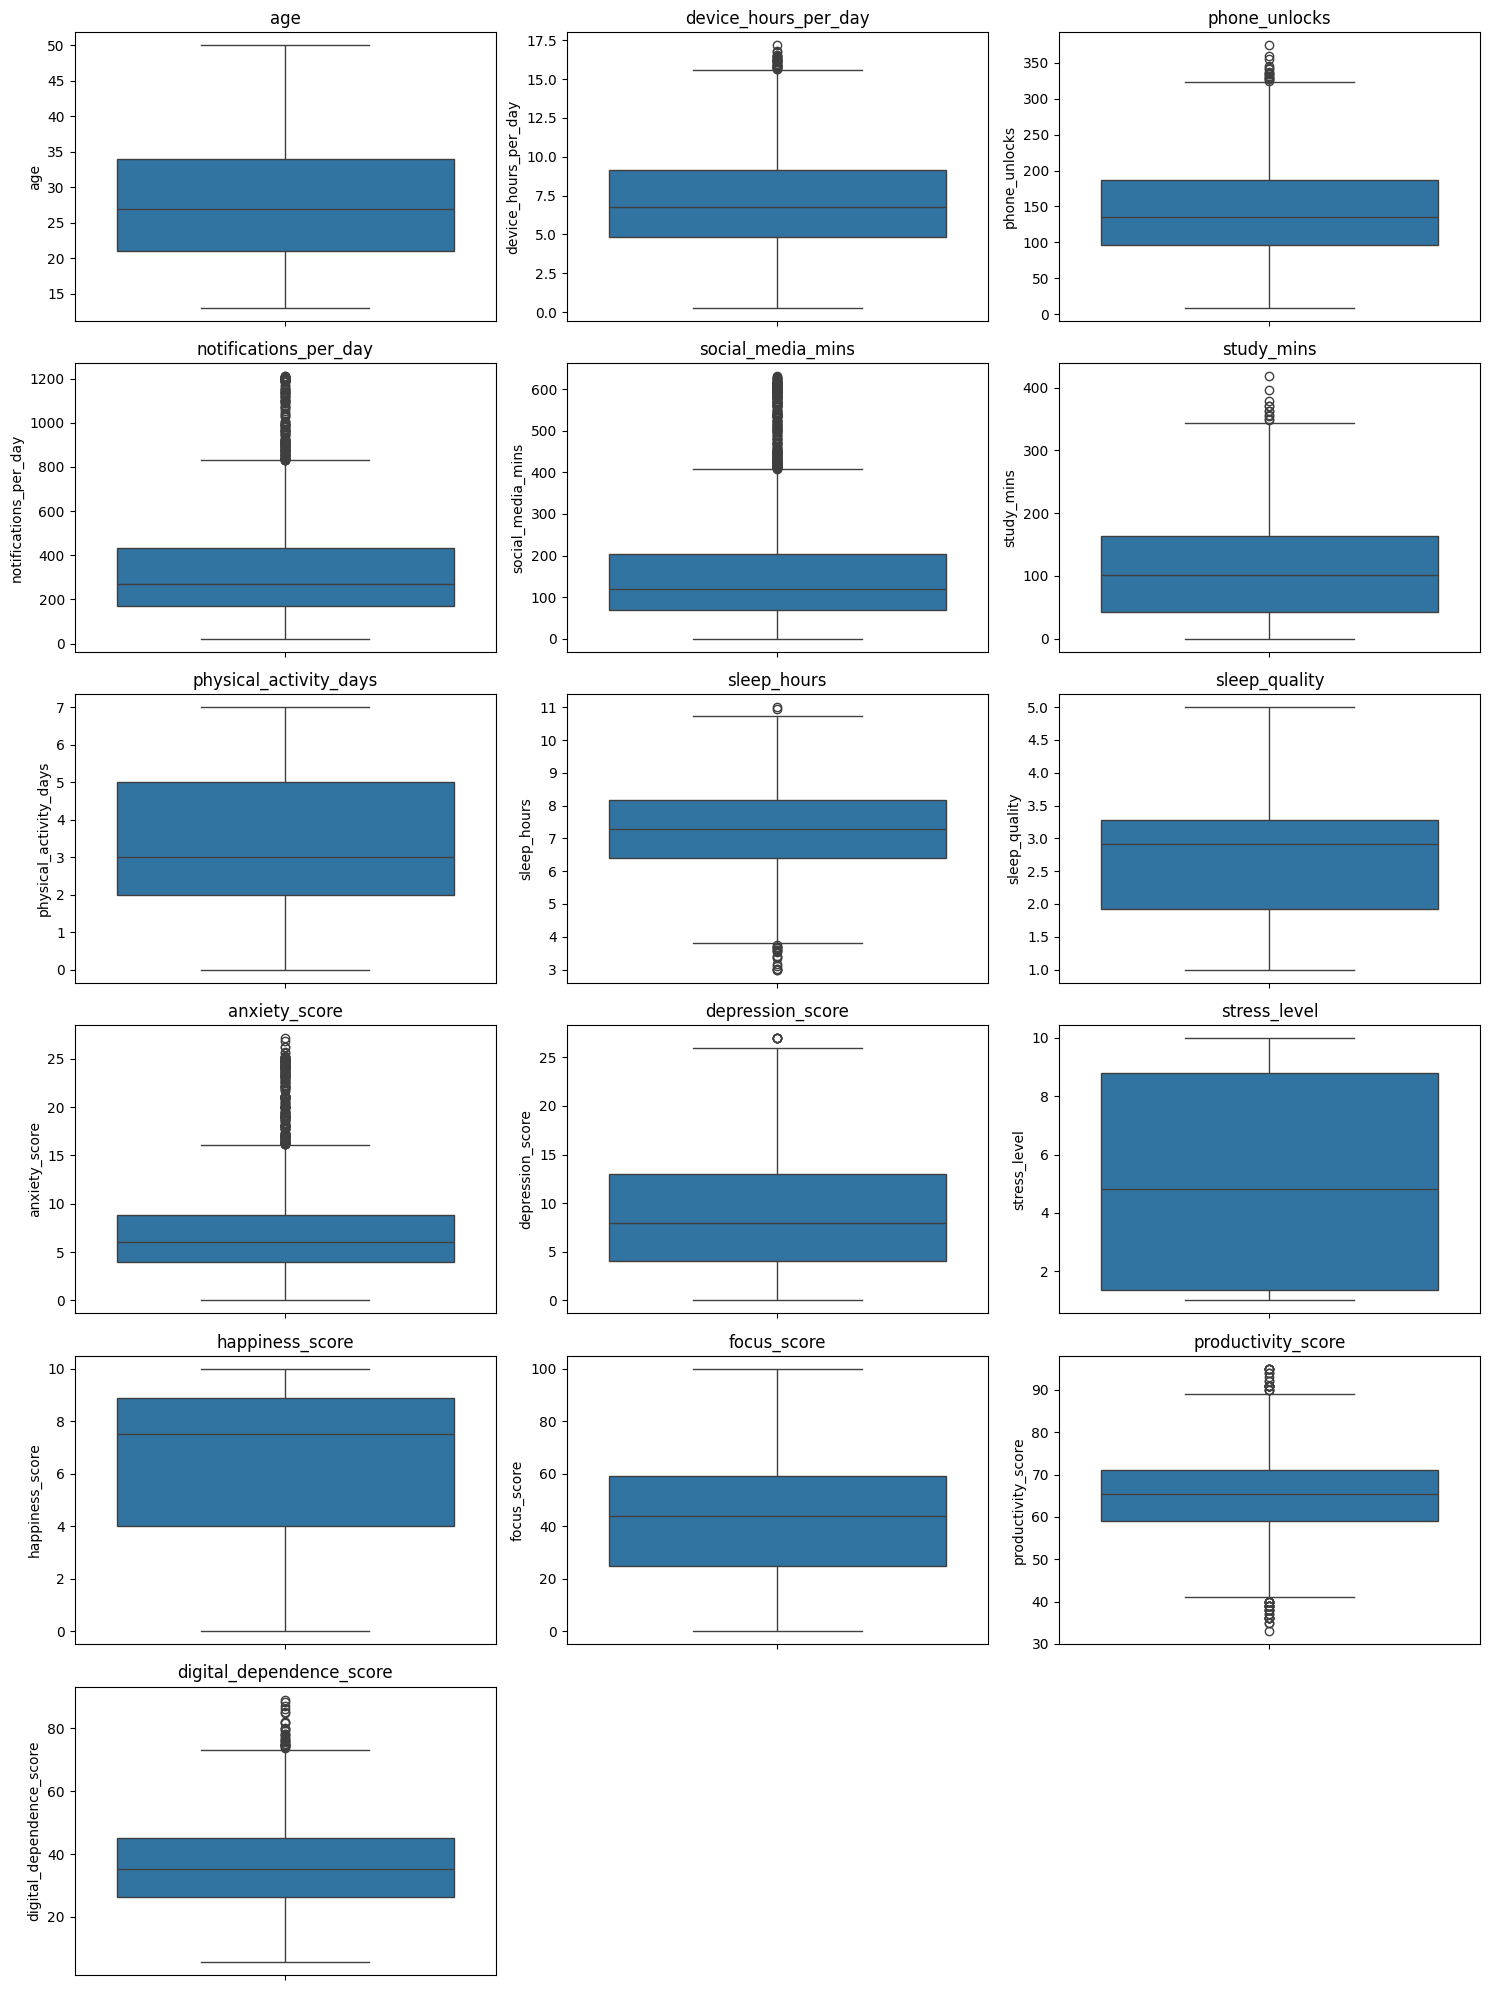

In [23]:
import math

numeric_cols = df_eda.select_dtypes(include=['int64', 'float64']).columns.drop(['high_risk_flag', 'income_ord', 'education_ord'])

n_cols = len(numeric_cols)
n_per_row = 3
n_rows = math.ceil(n_cols / n_per_row)

plt.figure(figsize=(15, 20))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_per_row, i + 1)
    sns.boxplot(y=df_eda[col])
    plt.title(col)

plt.tight_layout()
plt.show()

According to these plots many of the numeric features have outliers that most likely affect averages. However, I am not going to edit or remove these values because outliers in features like anxiety_score likely have strong correlation to higher risk of negative mental health.

### Feature Distributions

It can be helpful to see the frequencies of certain values in the data.

#### Numeric Features

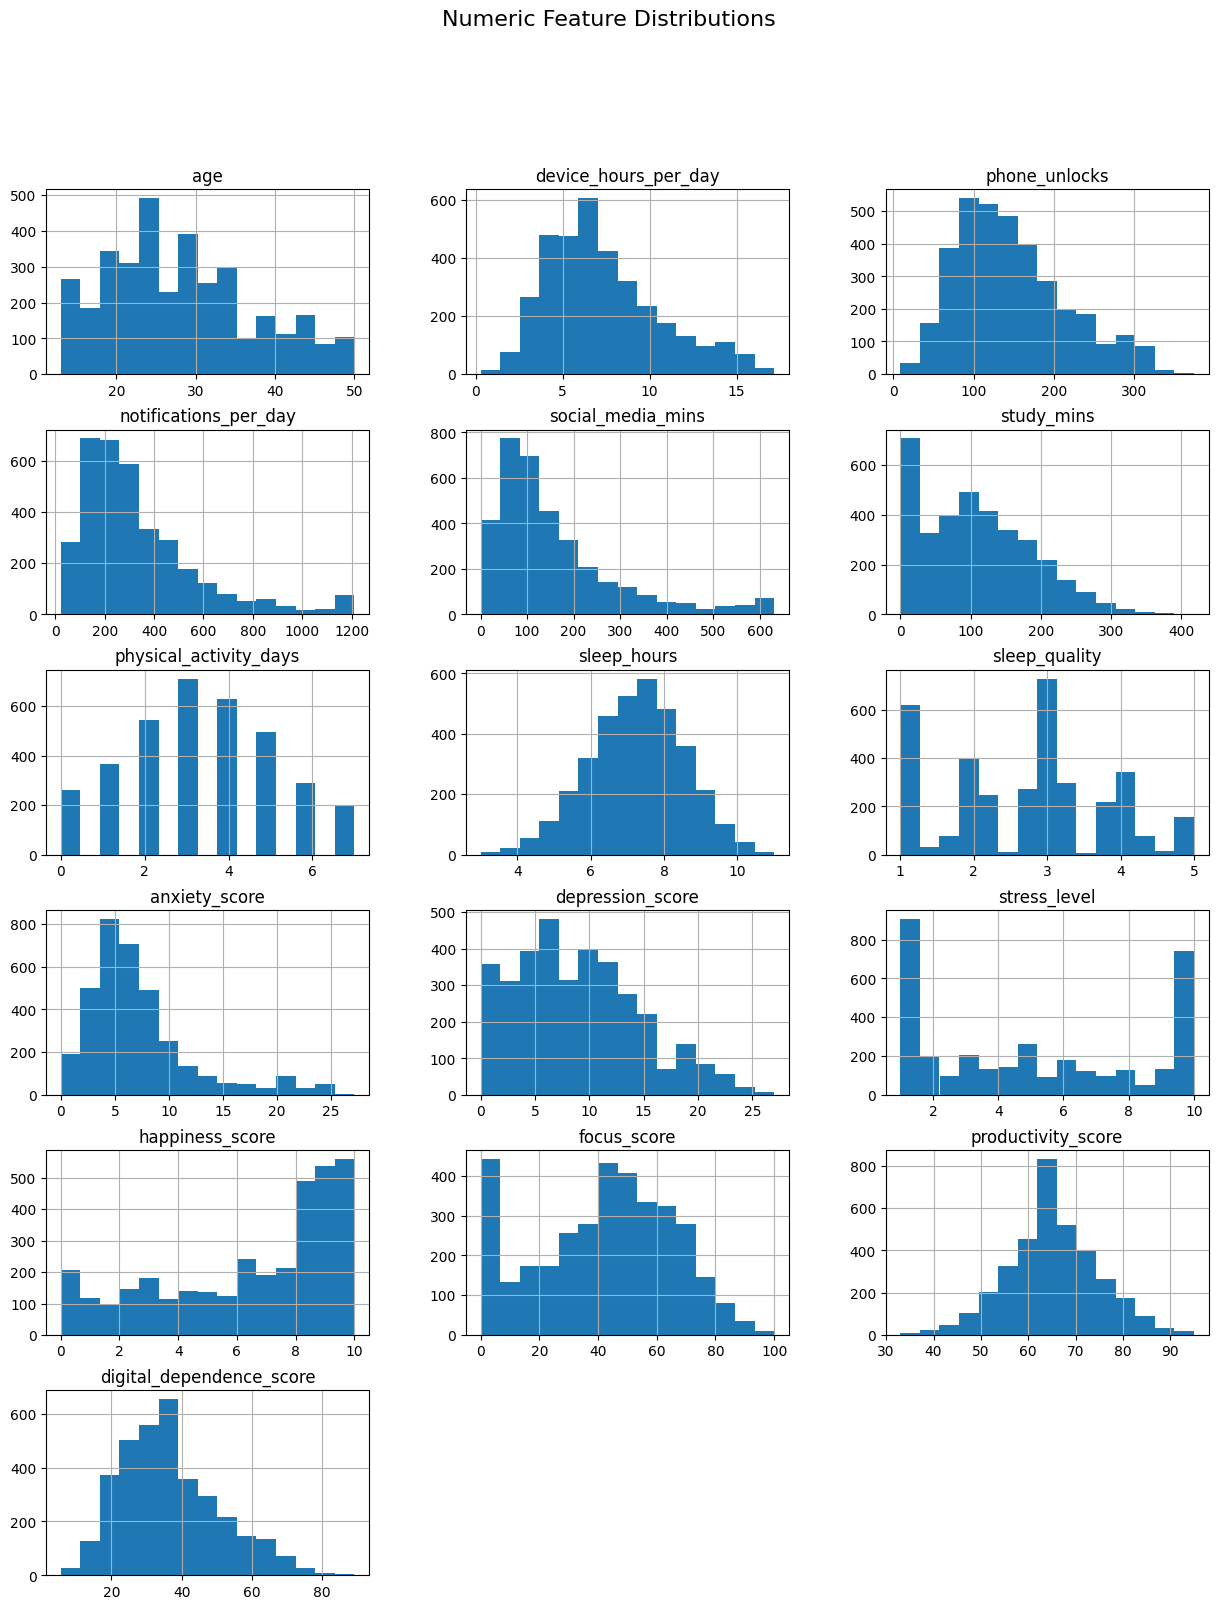

In [24]:
df_eda[numeric_cols].hist(bins=15, figsize=(15, 18), layout=(math.ceil(len(numeric_cols)/3),3))
plt.suptitle("Numeric Feature Distributions", fontsize=16)
plt.show()

Many of the features follow a normal distribution, but some skew farther towards lower or higher values. One stand-out distribution is stress_level where highest frequencies are low or high within its range.

#### Categorical Features

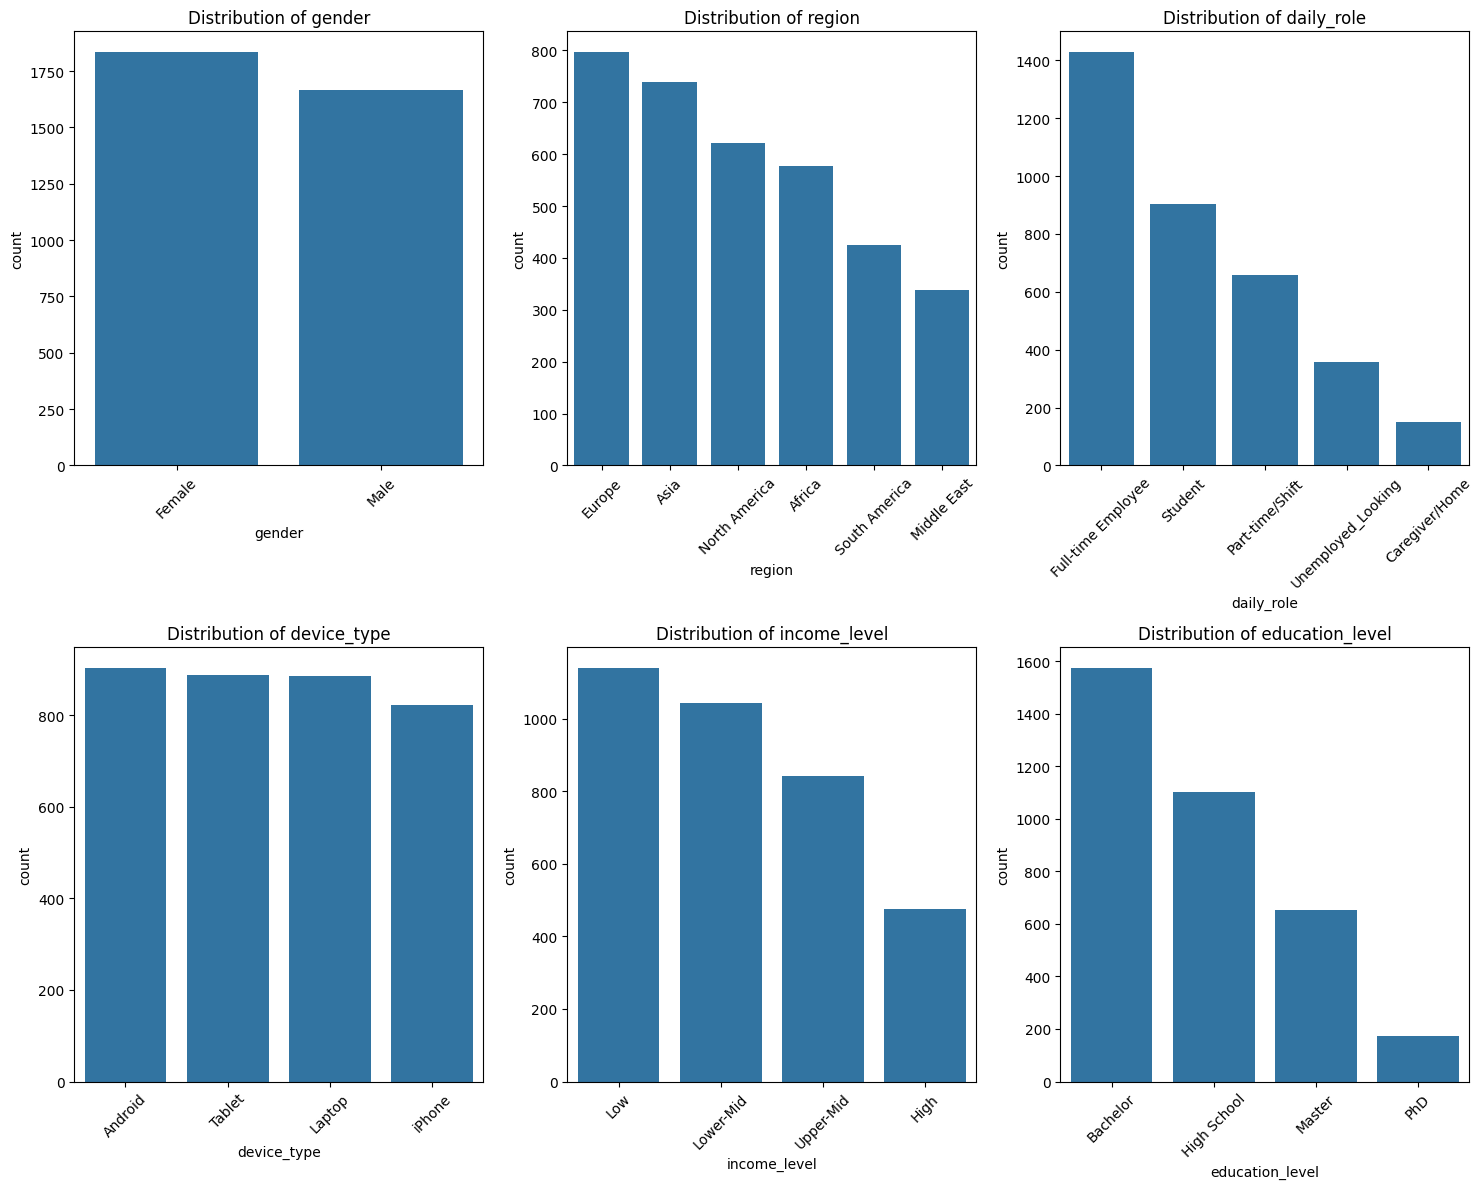

In [25]:
categorical_cols = ['gender', 'region', 'daily_role', 'device_type', 'income_level', 'education_level']

plt.figure(figsize=(15, 12))
for i, col in enumerate(categorical_cols):
    plt.subplot(math.ceil(len(categorical_cols)/3), 3, i+1)
    sns.countplot(data=df_eda, x=col, order=df_eda[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

### Comparing Training Features to Target Feature

To start narrowing down which features are most impactful to affect mental health, here I will analyze each feature to the high risk flag.

#### Numeric features

Analyzing each feature against the target high risk flag can show individual influences.

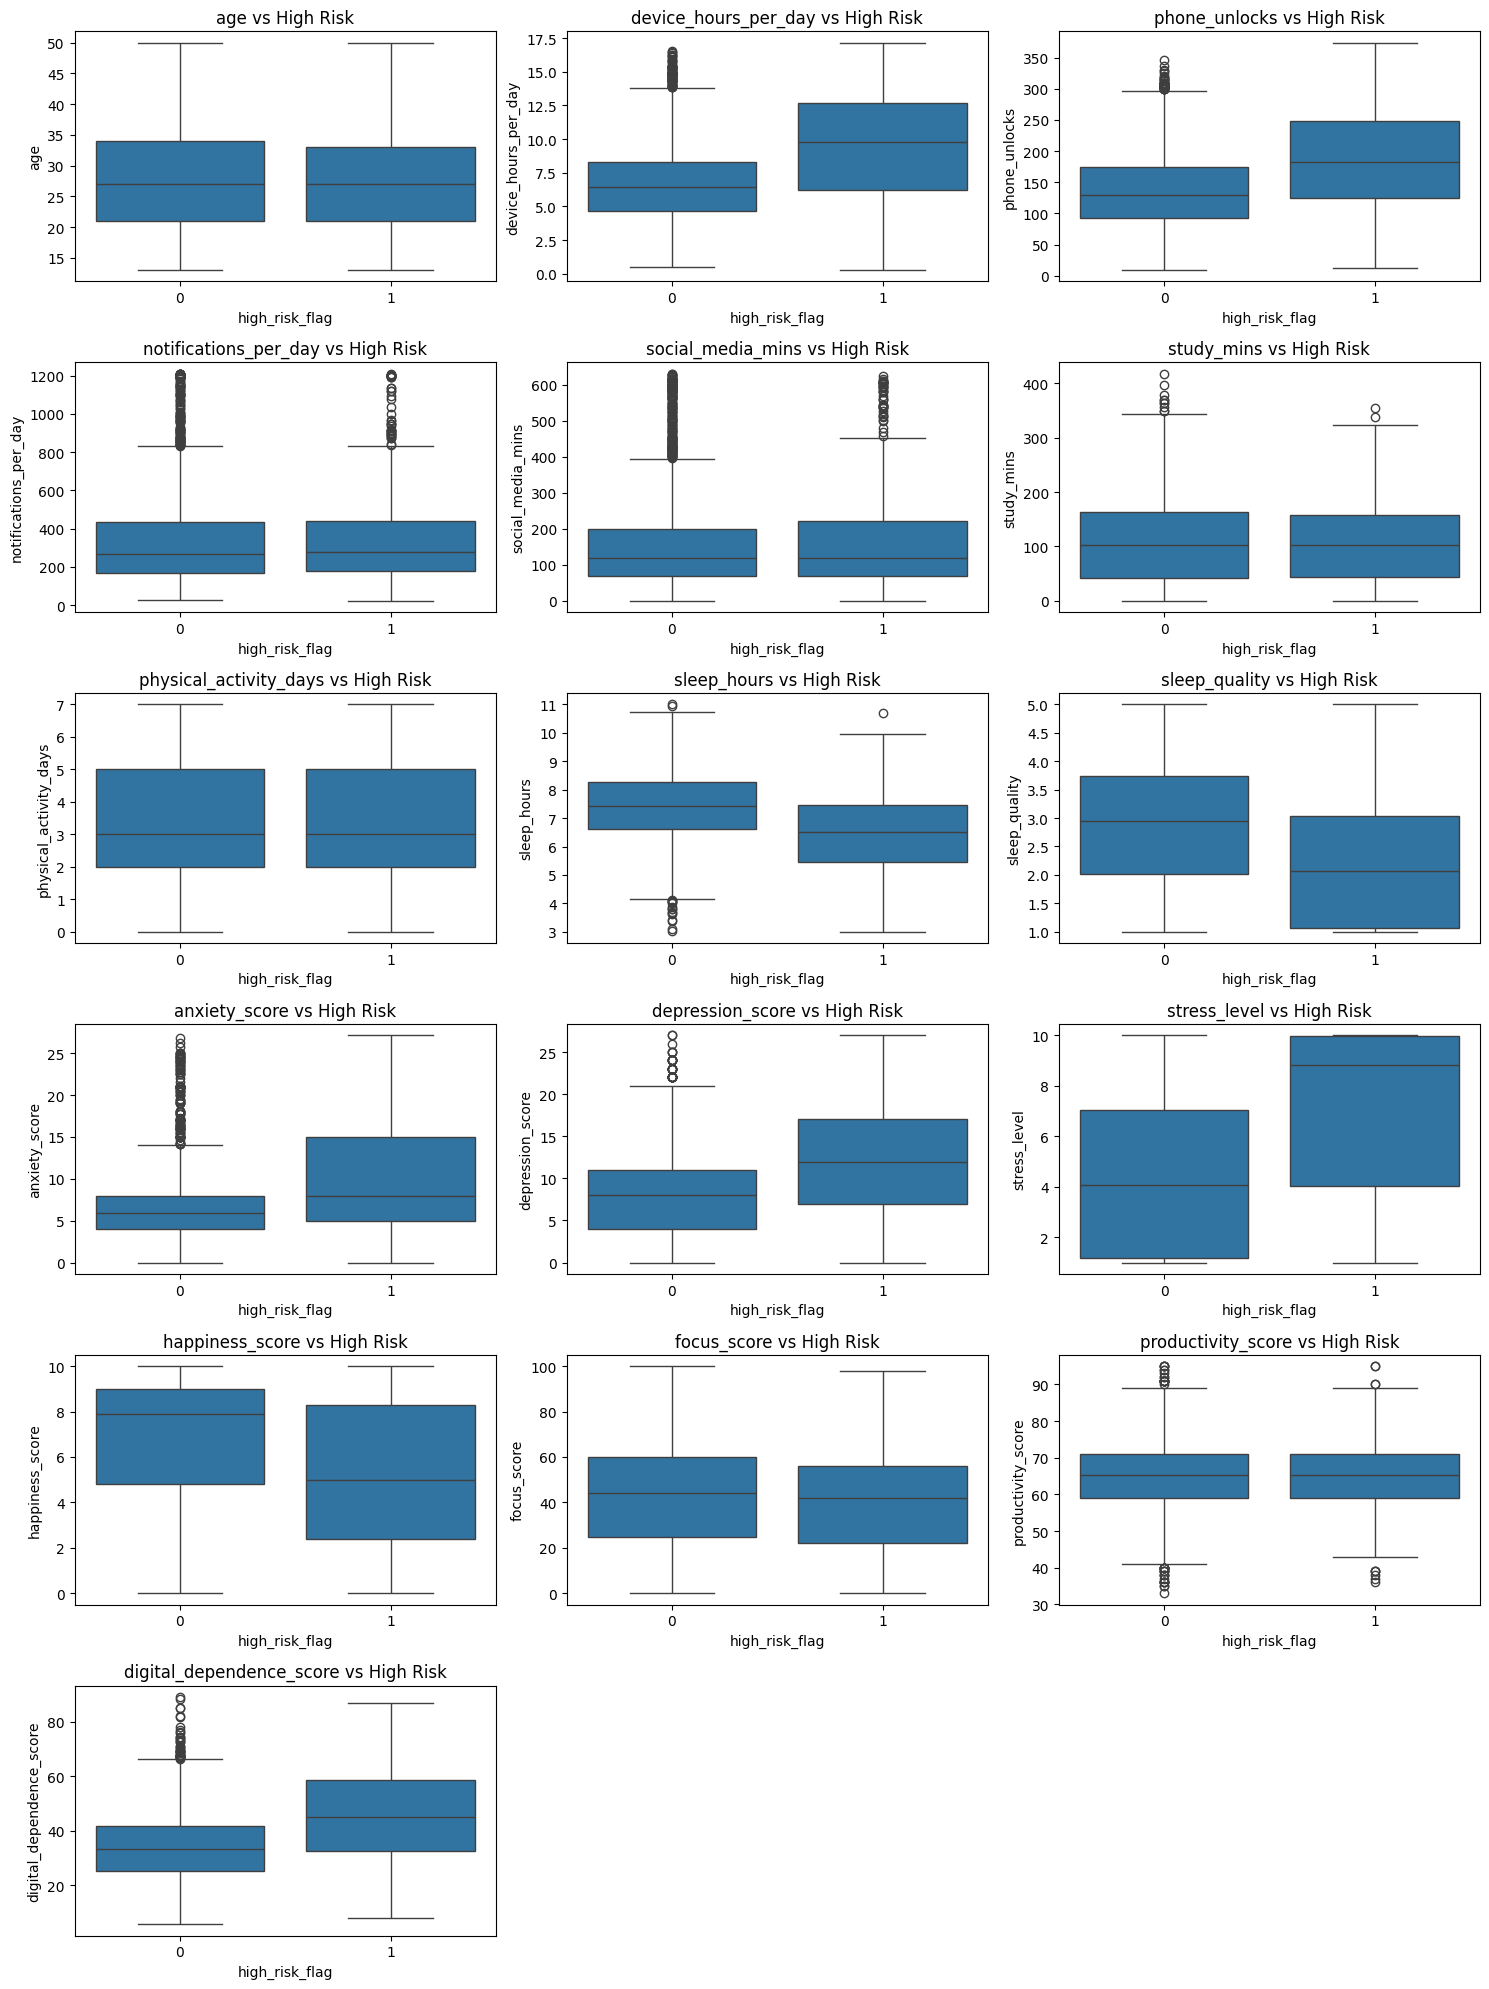

In [26]:
plt.figure(figsize=(15,20))
for i, col in enumerate(numeric_cols):
    plt.subplot(math.ceil(len(numeric_cols)/3), 3, i+1)
    sns.boxplot(x='high_risk_flag', y=col, data=df_eda)
    plt.title(f'{col} vs High Risk')
plt.tight_layout()
plt.show()

Here we can start to see which features can be more useful in predicting high risk. Vertical differences between the side by side box plots can mean the feature influences the target variable. For example, productivity_score and physical_activity_days have hardly any difference in their values when the target is true or false. However, higher values in device_hours_per_day and lower values in sleep_hours are more likely to appear when the target is true.

#### Categorical Variables

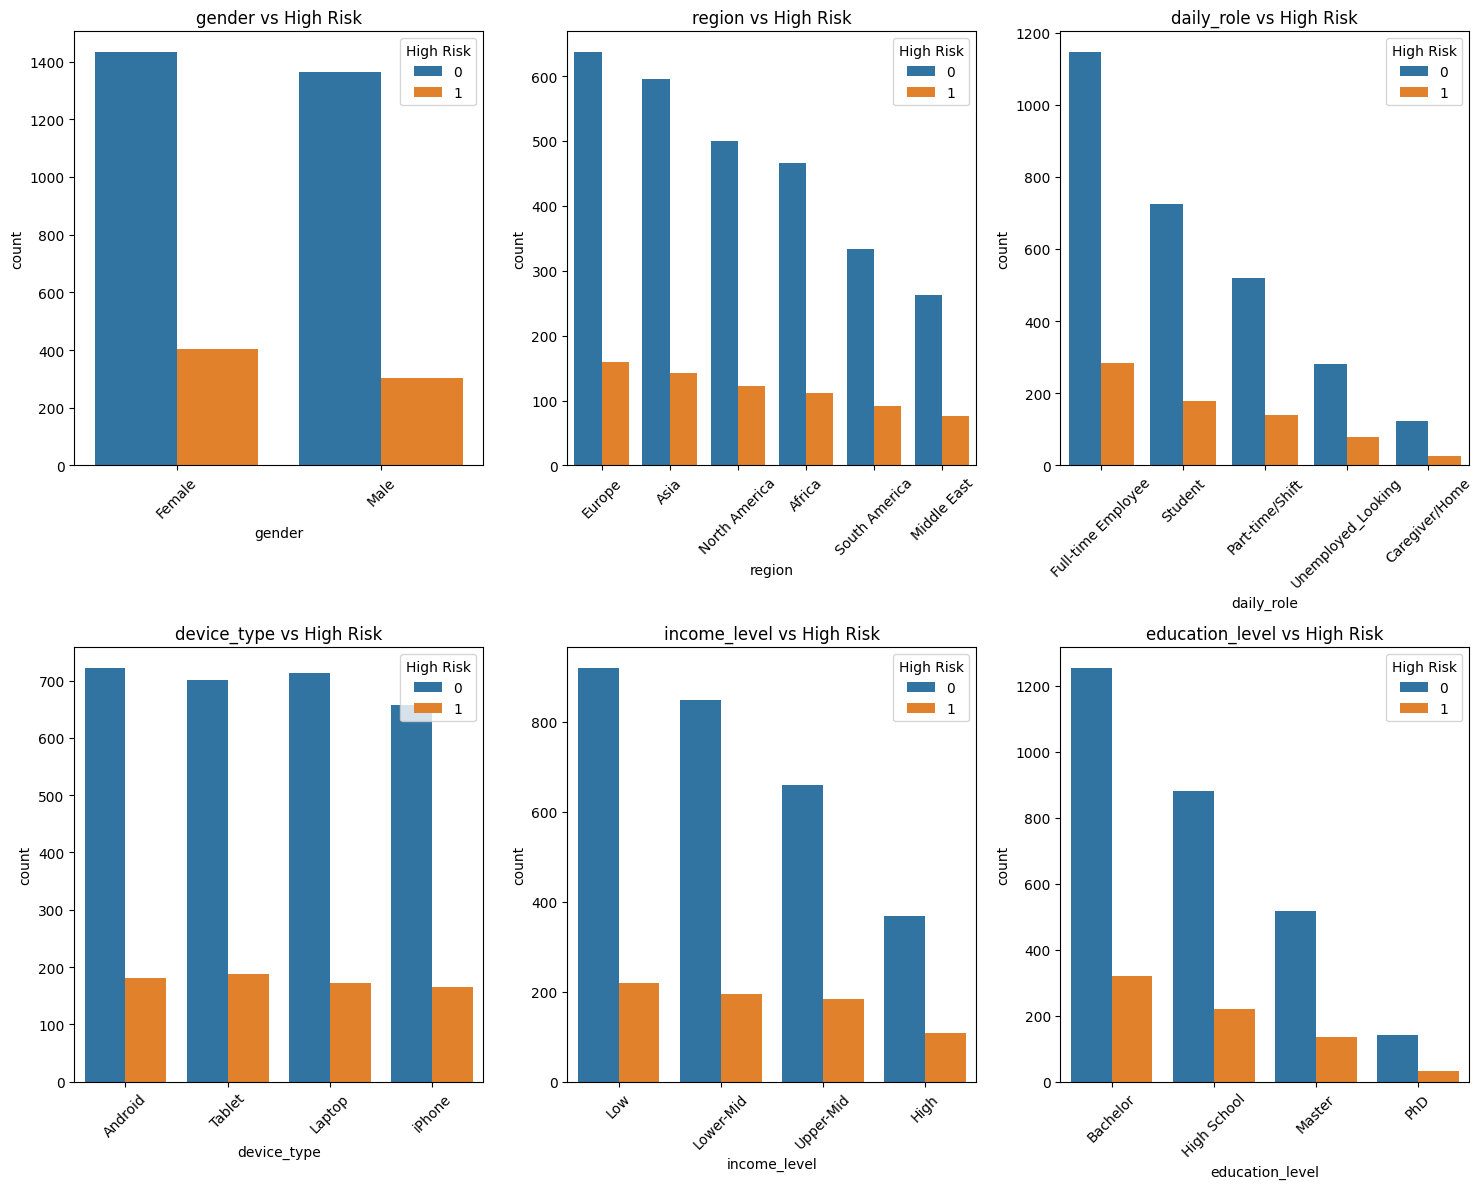

In [27]:
plt.figure(figsize=(15,12))
for i, col in enumerate(categorical_cols):
    plt.subplot(math.ceil(len(categorical_cols)/3), 3, i+1)
    sns.countplot(data=df_eda, x=col, hue='high_risk_flag', order=df_eda[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f'{col} vs High Risk')
    plt.legend(title='High Risk')
plt.tight_layout()
plt.show()

The categorical features don't show much influence on the target. The high risk entries for each follow the proportion of the data that they make up.

### Correlation Matrix

A correlation matrix is very useful in seeing linear relationships between the features. Positive numbers closer to one mean a stronger correlation where as one feature increases so does the other. Negative numbers closer to negative one mean that as one variable increases, the other is more likely to decrease.

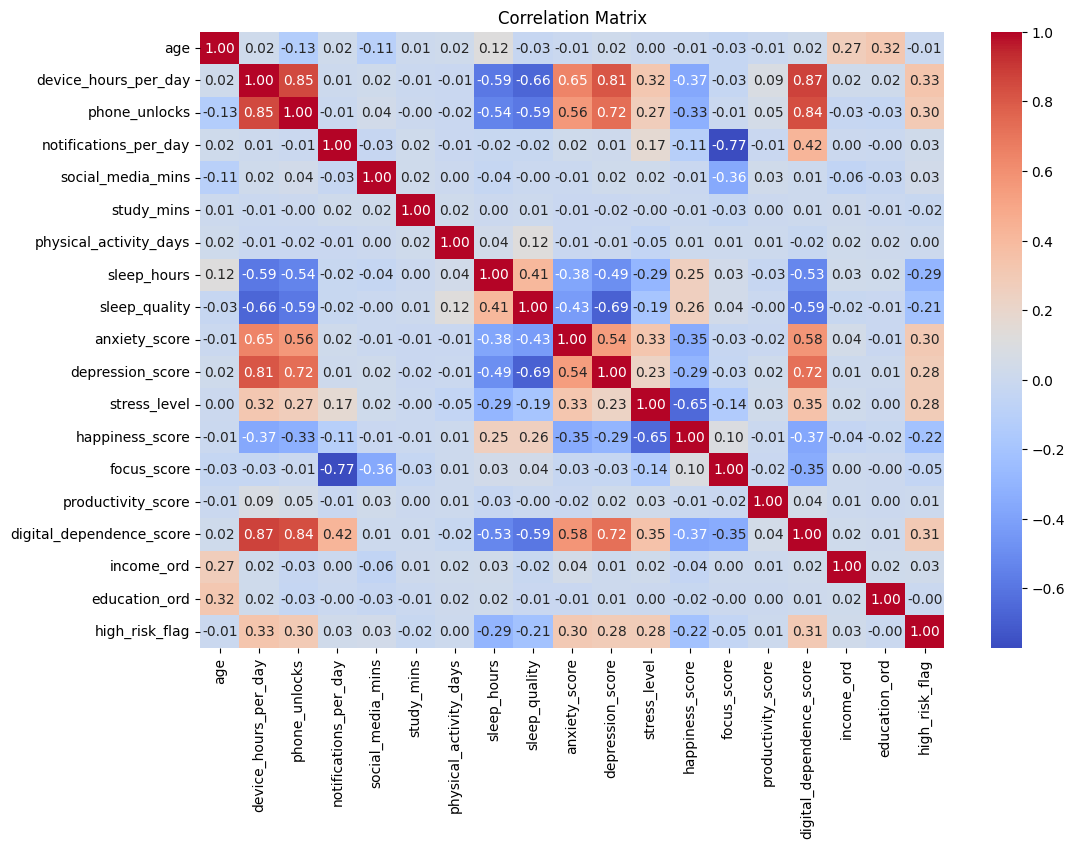

In [28]:
corr_cols = numeric_cols.tolist() + ['income_ord', 'education_ord', 'high_risk_flag']
corr_matrix = df_eda[corr_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

Some significant correlations here are between device_hours_per_day and depression, anxiety, and sleep related features. There is a relationship where as device hours increase so do depression and anxiety while sleep hours and quality are likely to decrease. The most significant correlations with the target variable are with device hours, phone unlocks, sleep hours and quality, stress, and digital dependence.

### Pair Plot

Using results from the analyses so far, I have picked some of the features that seem to have the most impact on the high risk target. The pair plot will show significant relationships between these feature that have noticable influence on the high risk flag.

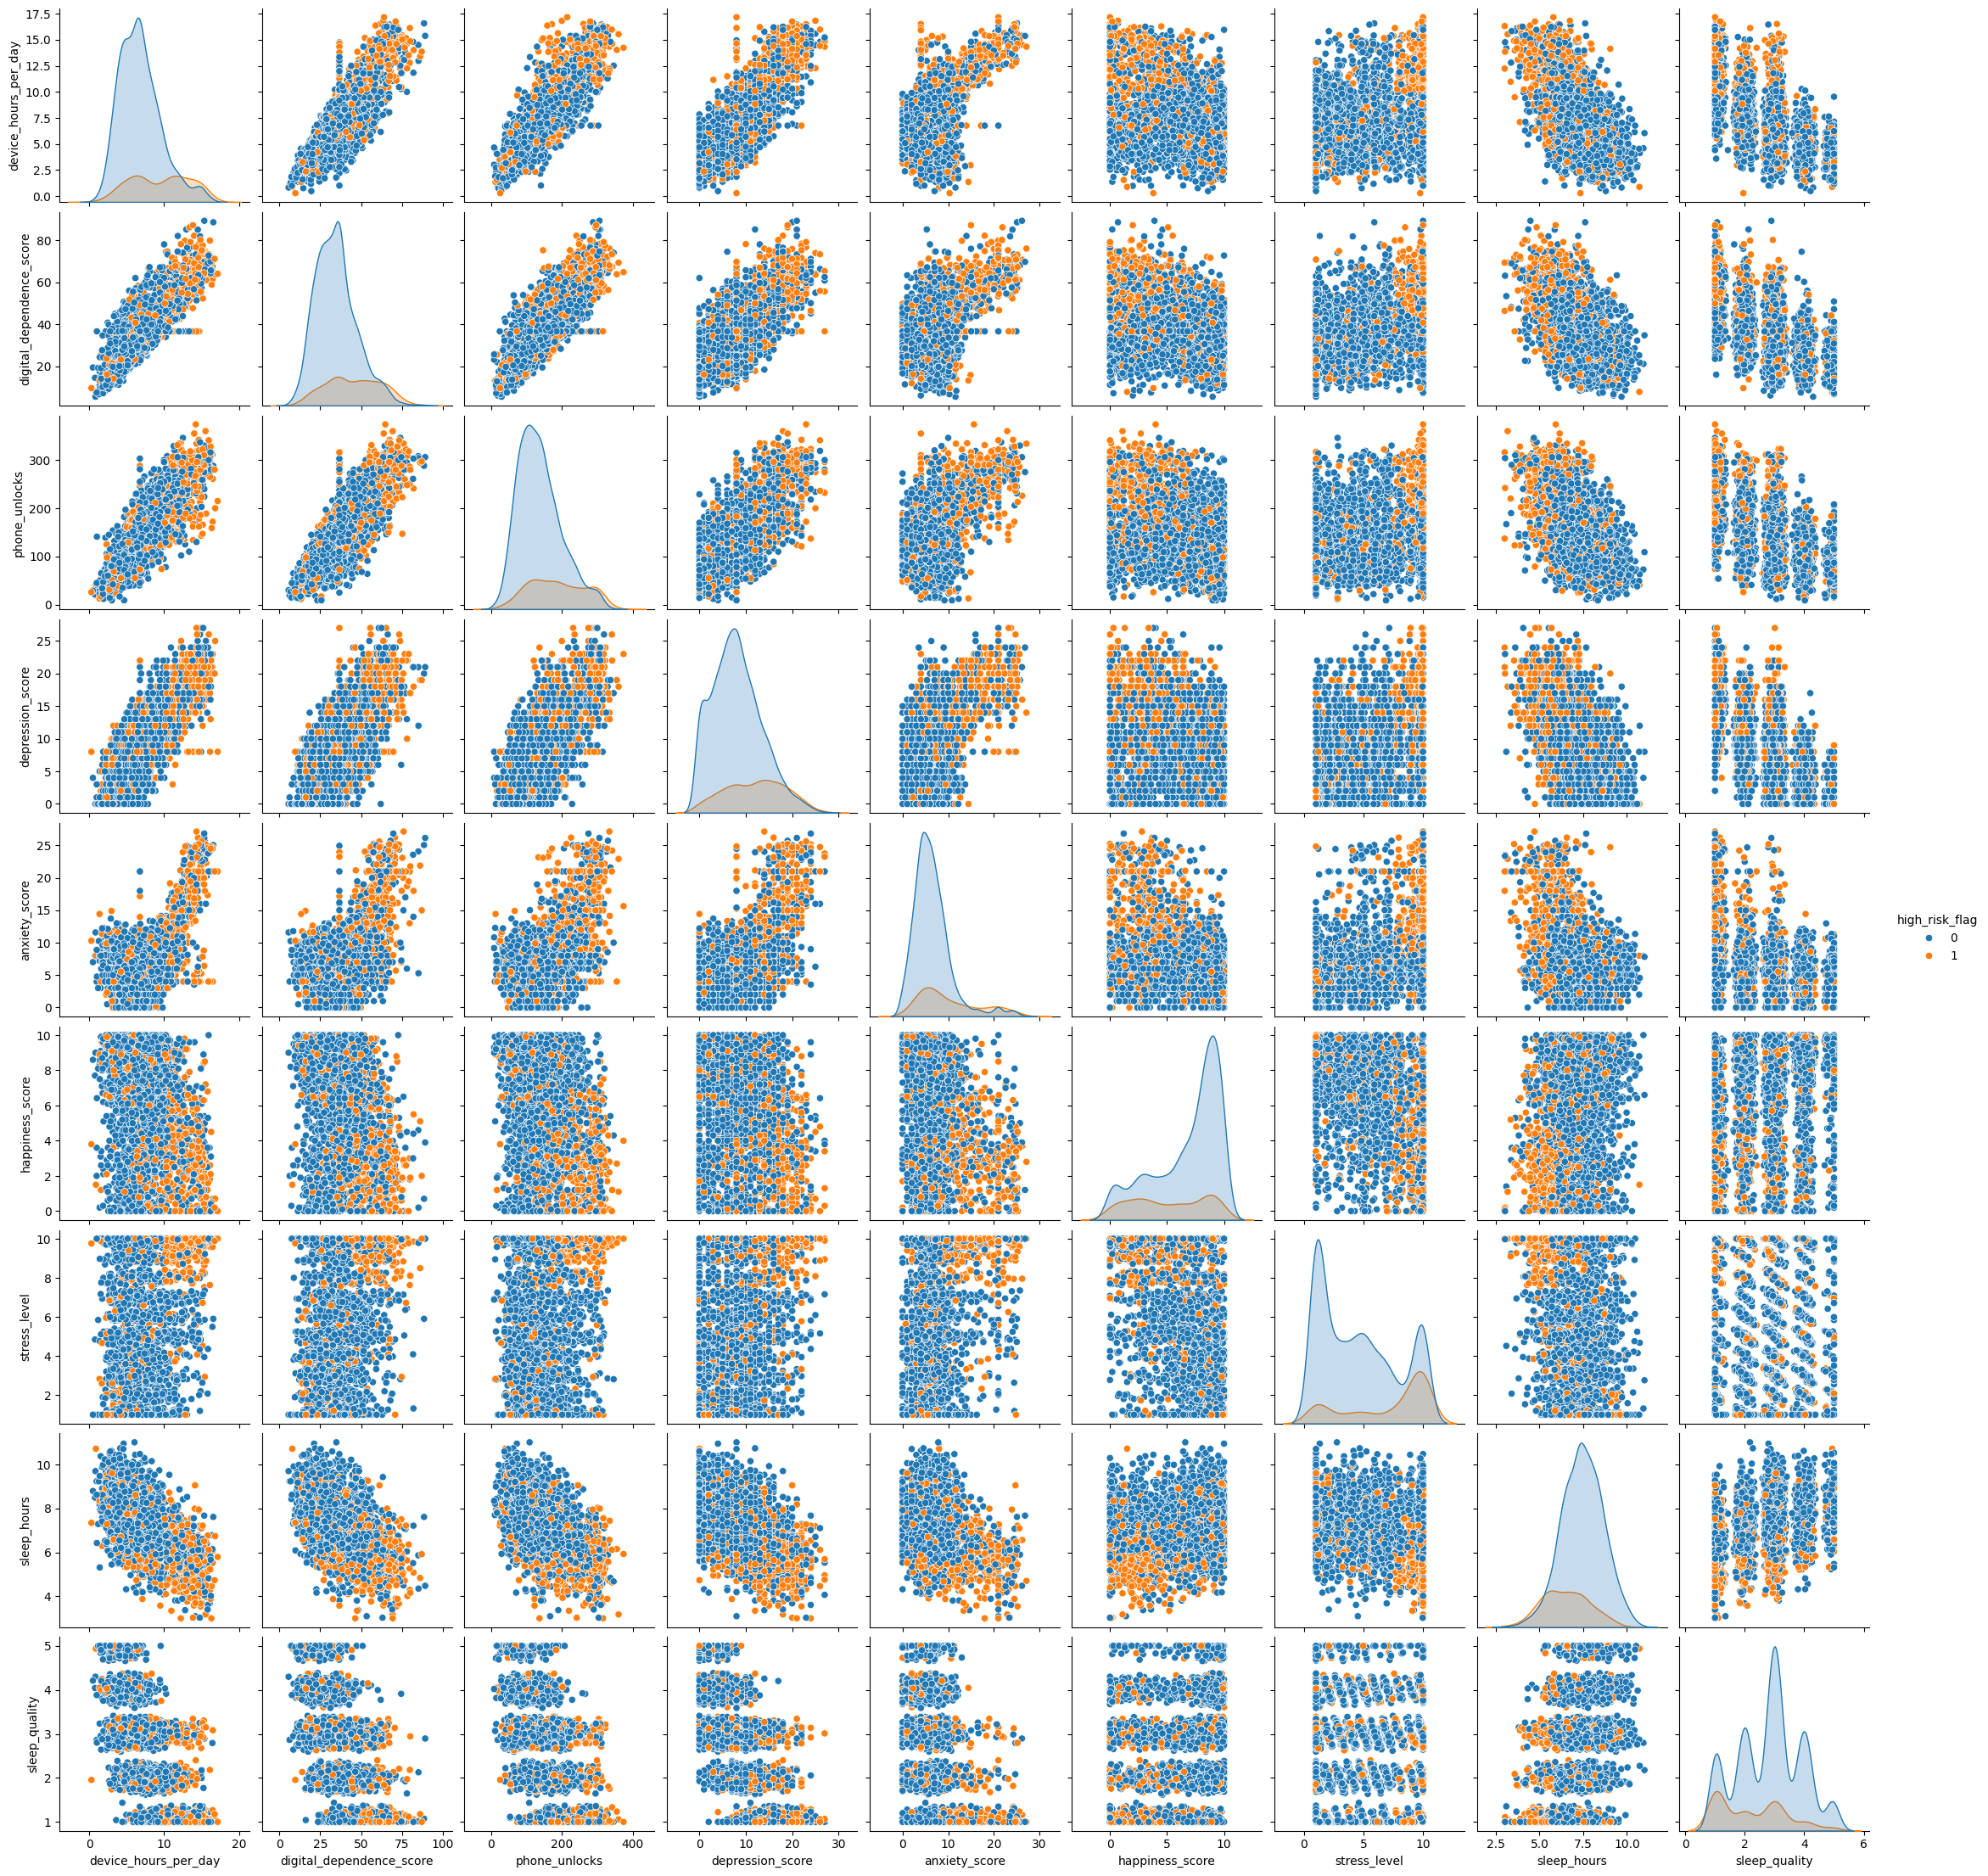

In [29]:
sig_feats = [
    'device_hours_per_day',
    'digital_dependence_score',
    'phone_unlocks',
    'depression_score',
    'anxiety_score',
    'happiness_score',
    'stress_level',
    'sleep_hours',
    'sleep_quality'
]
sns.pairplot(df_eda, vars=sig_feats, hue='high_risk_flag', diag_kind='kde')
plt.show()

In this pair plot, cornered clusters give the most information about which feature combinations influence high risk. For example the orange cluster in the top left of sleep_hours vs stress levels means that there is a high chance of being high risk at low hours of sleep with high stress levels.

Along the diagonal are kernel density estimation figures. The key thing to look for here is differences in the location of the peaks between target classes, especially overlaps. One of the most significant KDEs is for device hours where at high values the true target curve is above the false one. This does not necessarily prove causation but does show that there is a strong possibility of influence.

## Testing Different Machine Learning Models to Predict High Risk Target

Now that there is more information on which features may have strong influence on the target, I will test various ML models and evaluate them to see which performs best at predicting high risk.

In [30]:
# Function to visualize confusion matrices
def plot_confusion_matrix(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Low Risk', 'High Risk'],
        yticklabels=['Low Risk', 'High Risk']
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name} – Confusion Matrix")
    plt.show()

In [31]:
def plot_tree_feature_importance(model, X, model_name, top_n=10):
    
    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False).head(top_n)
    
    plt.figure(figsize=(8,5))
    feat_imp.plot(kind='barh', color='skyblue')
    plt.gca().invert_yaxis()
    plt.xlabel("Importance")
    plt.title(f"Top {top_n} Features – {model_name}")
    plt.show()


In [32]:
def plot_linear_feature_importance(model, X, model_name, top_n=10):
    
    importances = np.abs(model.coef_).flatten()
    feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False).head(top_n)

    plt.figure(figsize=(8,5))
    feat_imp.plot(kind='barh', color='salmon')
    plt.gca().invert_yaxis()
    plt.xlabel("Absolute Coefficient Value")
    plt.title(f"Top {top_n} Features – {model_name}")
    plt.show()

### Tree-Based Models

First, I will test decision tree based models. These will include RandomForest, DecisionTree, and an added GradientBoosting model from outside of what we did in class.

In [33]:
# Separate the training features from the target
X = df_training.drop(columns=['high_risk_flag'])
# X = df_training[sig_feats]
y = df_training['high_risk_flag']

In [34]:
# Perform the train-test split on the data
# stratify parameter is added to maintain similar target cases between training and test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

#### Decision Tree

In [35]:
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=3
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

Decision Tree Results


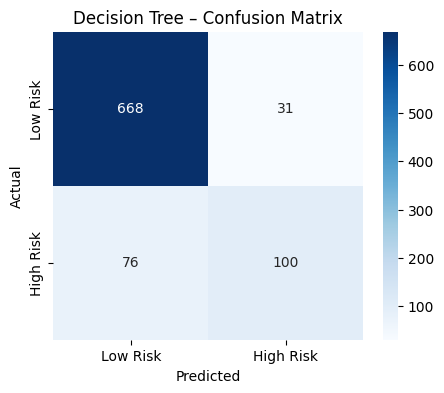

              precision    recall  f1-score   support

           0       0.90      0.96      0.93       699
           1       0.76      0.57      0.65       176

    accuracy                           0.88       875
   macro avg       0.83      0.76      0.79       875
weighted avg       0.87      0.88      0.87       875

Accuracy: 0.8777142857142857


In [36]:
y_pred_dt = dt.predict(X_test)

print("Decision Tree Results")
plot_confusion_matrix(y_test, y_pred_dt, 'Decision Tree')
print(classification_report(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

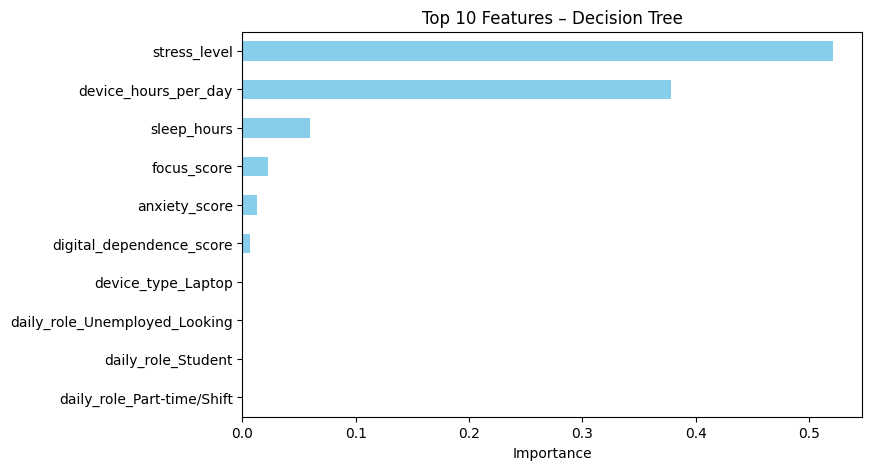

In [37]:
plot_tree_feature_importance(dt, X_train, "Decision Tree")

#### Random Forest

In [38]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=8,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8, n_estimators=200,
                       random_state=42)

Random Forest Results


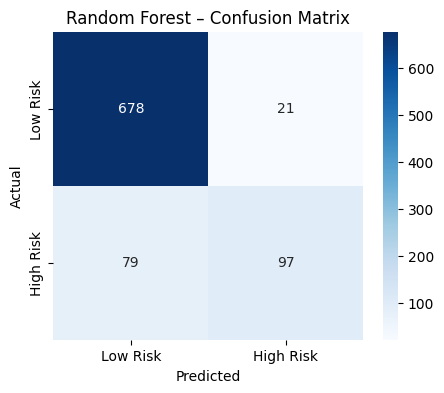

              precision    recall  f1-score   support

           0       0.90      0.97      0.93       699
           1       0.82      0.55      0.66       176

    accuracy                           0.89       875
   macro avg       0.86      0.76      0.80       875
weighted avg       0.88      0.89      0.88       875

Accuracy: 0.8857142857142857


In [39]:
y_pred_rf = rf.predict(X_test)

print("Random Forest Results")
plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest')
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

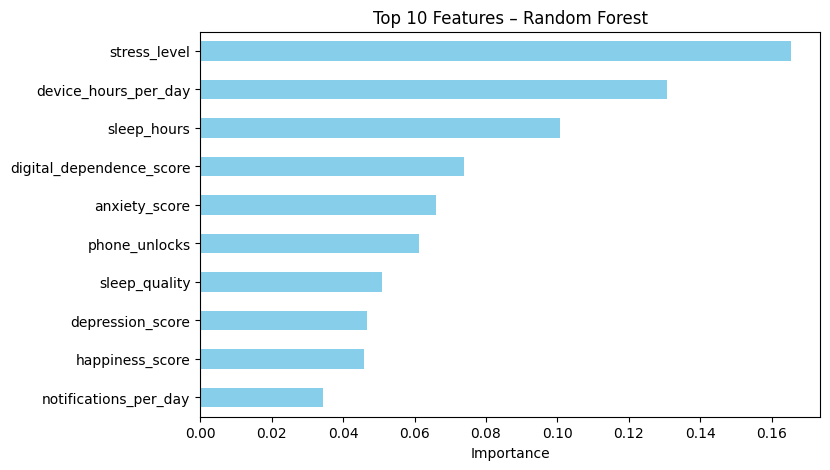

In [40]:
plot_tree_feature_importance(rf, X_train, "Random Forest")

#### Gradient Boosted

In [41]:
gb = GradientBoostingClassifier(
    random_state=42,
    learning_rate=0.1,
    n_estimators=200,
    max_depth=4
)

gb.fit(X_train, y_train)

GradientBoostingClassifier(max_depth=4, n_estimators=200, random_state=42)

Gradient Boosting Results


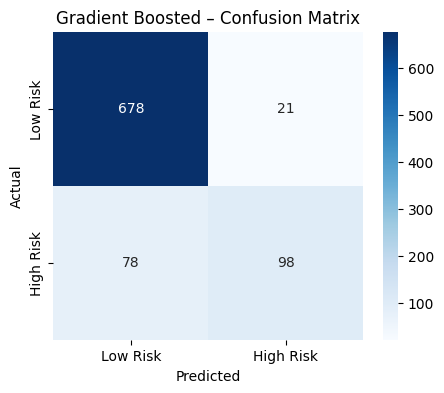

              precision    recall  f1-score   support

           0       0.90      0.97      0.93       699
           1       0.82      0.56      0.66       176

    accuracy                           0.89       875
   macro avg       0.86      0.76      0.80       875
weighted avg       0.88      0.89      0.88       875

Accuracy: 0.8868571428571429


In [42]:
y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Results")
plot_confusion_matrix(y_test, y_pred_gb, 'Gradient Boosted')
print(classification_report(y_test, y_pred_gb))
print("Accuracy:", accuracy_score(y_test, y_pred_gb))

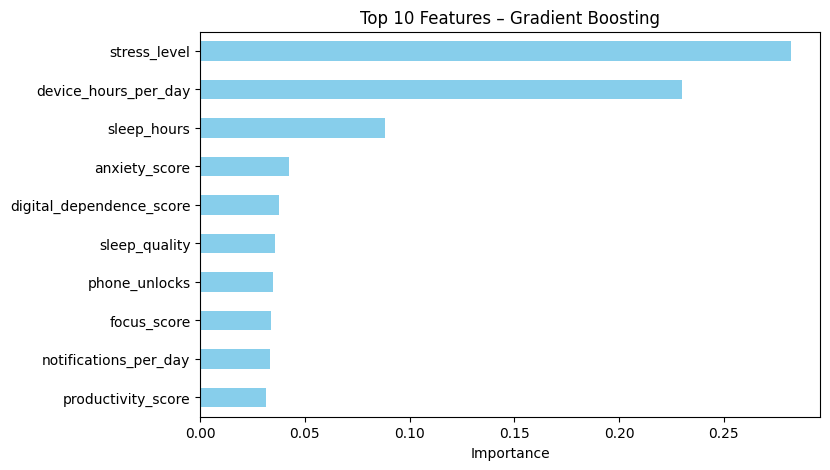

In [43]:
plot_tree_feature_importance(gb, X_train, "Gradient Boosting")

#### Tree Evaluation

After some minor tuning for each of the tree models, DecisionTree, RandomForest, and GradientBoost all performed similarly. Recall and f1-scores for true target values were very close between each of the models. According to the confusion matrices, false negatives were the most prevelant and false positives were also present. This is likely a result of the true target cases that do not strictly follow the patterns of the majority in regard to features with the most importance. All three tree models determined stress_level, device_hours_per_day, and sleep_hours to be the top three features of importance. Further model tuning and feature engineering is likely needed to improve results.

### Linear-Based Models

Based on the correlation matrix established during EDA, there are multiple linear relationships present in the data. Now I will train multiple linear-based models to see if these relationships may help predict the target feature.

In [44]:
# X_scaled = df_training_scaled.drop(columns=['high_risk_flag'])
X_scaled = df_training_scaled[sig_feats]
y = df_training_scaled['high_risk_flag']

In [45]:
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

#### Logistic Regression

In [46]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

Logistic Regression Results


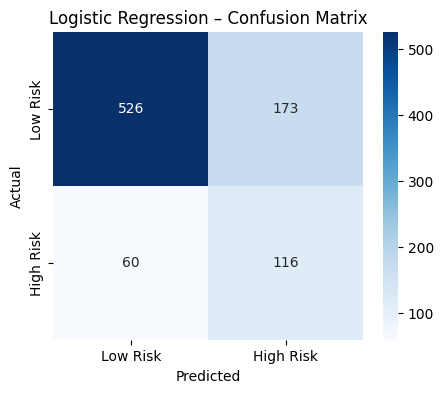

              precision    recall  f1-score   support

           0       0.90      0.75      0.82       699
           1       0.40      0.66      0.50       176

    accuracy                           0.73       875
   macro avg       0.65      0.71      0.66       875
weighted avg       0.80      0.73      0.75       875

Accuracy: 0.7337142857142858


In [47]:
y_pred_lr = log_reg.predict(X_test_scaled)

print("Logistic Regression Results")
plot_confusion_matrix(y_test, y_pred_lr, "Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

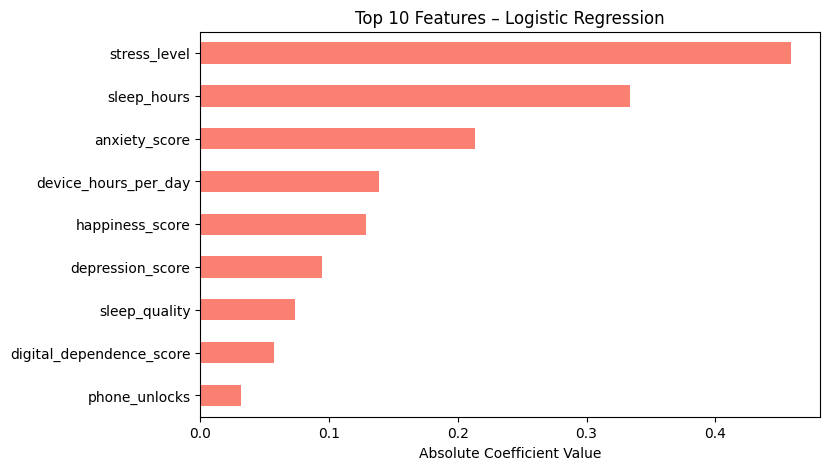

In [48]:
plot_linear_feature_importance(log_reg, X_train_scaled, "Logistic Regression")

#### Linear SVM

In [49]:
svm = LinearSVC(
    class_weight='balanced',
    random_state=42
)

svm.fit(X_train_scaled, y_train)

LinearSVC(class_weight='balanced', random_state=42)

Linear SVM Results


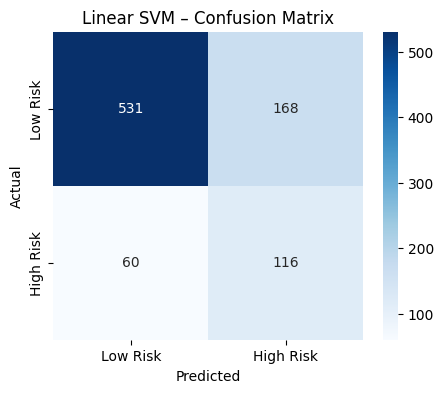

              precision    recall  f1-score   support

           0       0.90      0.76      0.82       699
           1       0.41      0.66      0.50       176

    accuracy                           0.74       875
   macro avg       0.65      0.71      0.66       875
weighted avg       0.80      0.74      0.76       875

Accuracy: 0.7394285714285714


In [50]:
y_pred_svm = svm.predict(X_test_scaled)

print("Linear SVM Results")
plot_confusion_matrix(y_test, y_pred_svm, "Linear SVM")
print(classification_report(y_test, y_pred_svm))
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

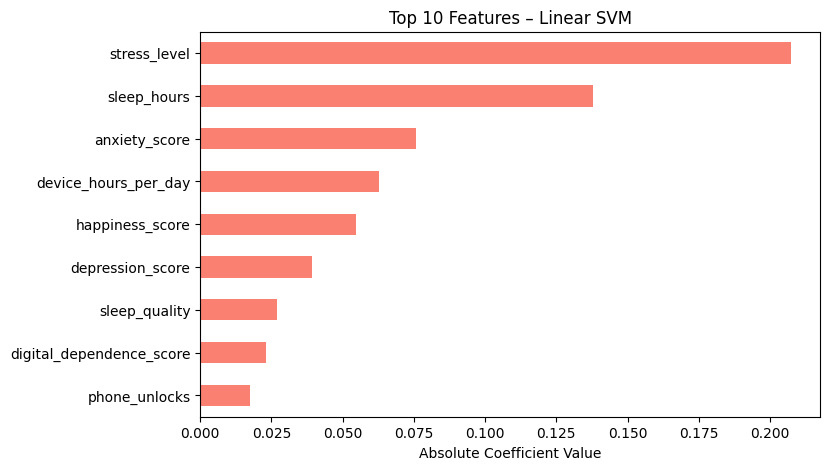

In [51]:
plot_linear_feature_importance(svm, X_train_scaled, "Linear SVM")

#### SGD

In [52]:
sgd = SGDClassifier(
    loss='log_loss',
    max_iter=5000,
    class_weight='balanced',
    random_state=42
)

sgd.fit(X_train_scaled, y_train)

SGDClassifier(class_weight='balanced', loss='log_loss', max_iter=5000,
              random_state=42)

SGD Results


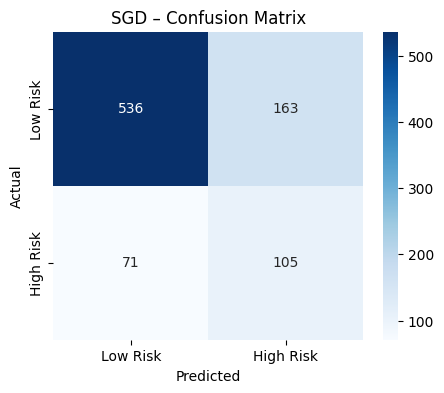

              precision    recall  f1-score   support

           0       0.88      0.77      0.82       699
           1       0.39      0.60      0.47       176

    accuracy                           0.73       875
   macro avg       0.64      0.68      0.65       875
weighted avg       0.78      0.73      0.75       875

Accuracy: 0.7325714285714285


In [53]:
y_pred_sgd = sgd.predict(X_test_scaled)

print("SGD Results")
plot_confusion_matrix(y_test, y_pred_sgd, "SGD")
print(classification_report(y_test, y_pred_sgd))
print("Accuracy:", accuracy_score(y_test, y_pred_sgd))

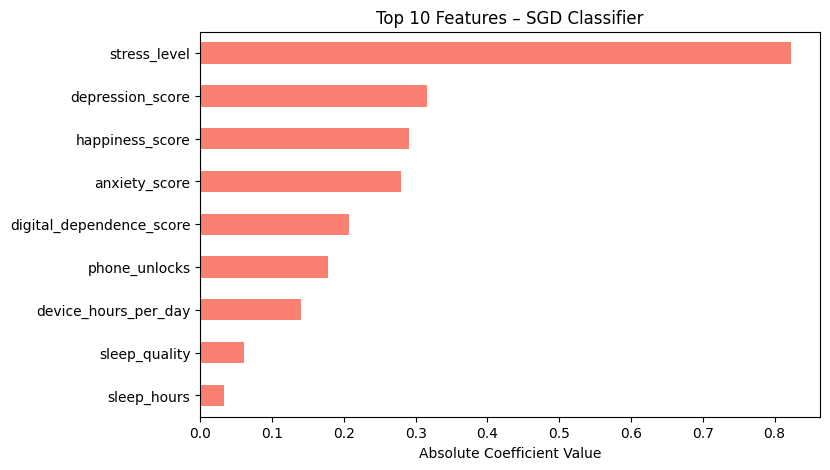

In [54]:
plot_linear_feature_importance(sgd, X_train_scaled, "SGD Classifier")

#### SVC

In [55]:
svc = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=42
)

svc.fit(X_train_scaled, y_train)

SVC(class_weight='balanced', probability=True, random_state=42)

SVC Results


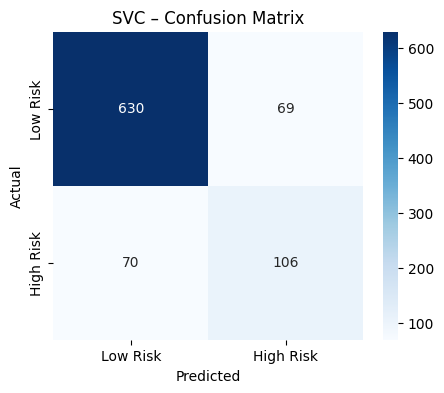

              precision    recall  f1-score   support

           0       0.90      0.90      0.90       699
           1       0.61      0.60      0.60       176

    accuracy                           0.84       875
   macro avg       0.75      0.75      0.75       875
weighted avg       0.84      0.84      0.84       875

Accuracy: 0.8411428571428572


In [56]:
y_pred_svc = svc.predict(X_test_scaled)

print("SVC Results")
plot_confusion_matrix(y_test, y_pred_svc, "SVC")
print(classification_report(y_test, y_pred_svc))
print("Accuracy:", accuracy_score(y_test, y_pred_svc))

#### Linear Evaluation

Each of the linear models struggled to predict the target. Initial training was done with the full df_training_scaled dataframe, but this yielded even worse results (especially for sgd). I reduced the amount of noise in the data by only including the features that showed significant linear realationships and this improved performance. The SVC with an 'rbf' kernel had the best results with far fewer false positives. Further tuning and data processing is needed to tune linear model training.

### k-Nearest Neighbors

For added depth I will also train a K nearest neighbor model. This will determine if the target cases are in close proximity to eahcother in the data. My initial thoughts are that this won't be the most effective since there are true target case outliers.

In [57]:
from sklearn.neighbors import KNeighborsClassifier

In [58]:
knn = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance'
)

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(weights='distance')

KNN Results


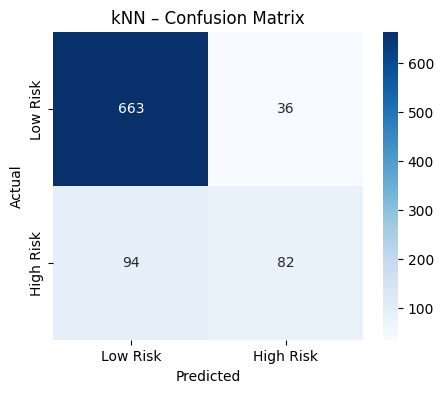

              precision    recall  f1-score   support

           0       0.88      0.95      0.91       699
           1       0.69      0.47      0.56       176

    accuracy                           0.85       875
   macro avg       0.79      0.71      0.73       875
weighted avg       0.84      0.85      0.84       875

Accuracy: 0.8514285714285714


In [59]:
y_pred_knn = knn.predict(X_test_scaled)

print('KNN Results')
plot_confusion_matrix(y_test, y_pred_knn, "kNN")
print(classification_report(y_test, y_pred_knn))
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

#### KNN Evaluation

The KNN model resulted in very low recall for the true target cases. According to the confusion matrix it had more false negatives than true positives meaning that it struggles with predicting the target.

### Clustering

For the final set of models I will be evaluating both kmeans and hierarchical clustering. All previous models were trained using supervised learning, so evaluating the data using unsupervised learning may provide more insight. 

In [60]:
X_cluster = df_training_scaled[sig_feats]

#### KMeans

In [61]:
kmeans = KMeans(n_clusters=2, random_state=42)
cluster_labels_km = kmeans.fit_predict(X_cluster)

df_clustered_km = df_training_scaled.copy()
df_clustered_km['cluster'] = cluster_labels_km

For additional analysis outside of what we did in class, I am adding the silhouette score for both forms of clustering. This will represent how distinct the clusters are on a scale of 0 to 1.

In [62]:
from sklearn.metrics import silhouette_score

sil_km = silhouette_score(X_cluster, cluster_labels_km)
print("K-Means Silhouette Score:", sil_km)

K-Means Silhouette Score: 0.3689652206563912


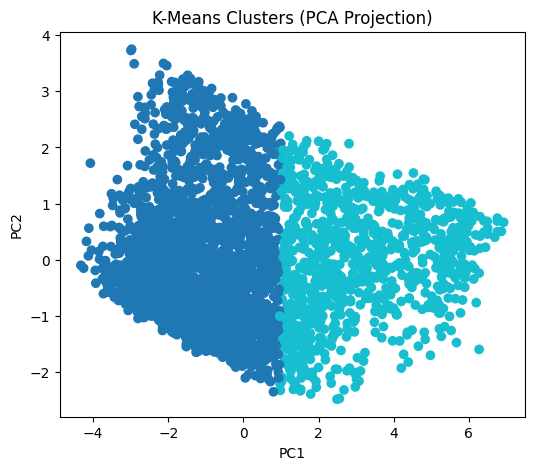

In [63]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels_km, cmap='tab10')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters (PCA Projection)")
plt.show()

Crosstab will allow comparing the clusters to the target feature. It essentially shows the distribution of each target class within each cluster.

In [64]:
pd.crosstab(df_clustered_km['cluster'], df_clustered_km['high_risk_flag'], normalize='index')

high_risk_flag,0,1
cluster,,
0,0.879121,0.120879
1,0.582983,0.417017


#### Hierarchical

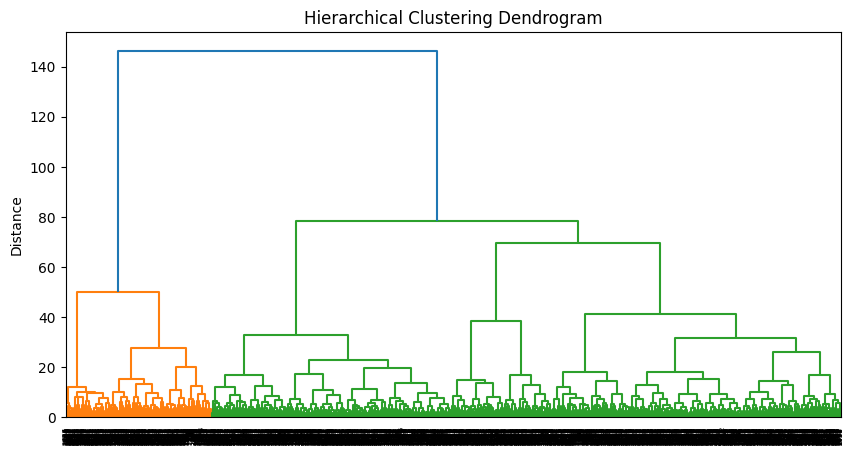

In [65]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_cluster, method='ward')

plt.figure(figsize=(10,5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.ylabel("Distance")
plt.show()

In [66]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

cluster_labels_hc = hc.fit_predict(X_cluster)

df_clustered_hc = df_training_scaled.copy()
df_clustered_hc['cluster'] = cluster_labels_hc

In [67]:
sil_hc = silhouette_score(X_cluster, cluster_labels_hc)
print("Hierarchical Clustering Silhouette Score:", sil_hc)

Hierarchical Clustering Silhouette Score: 0.36386277082366253


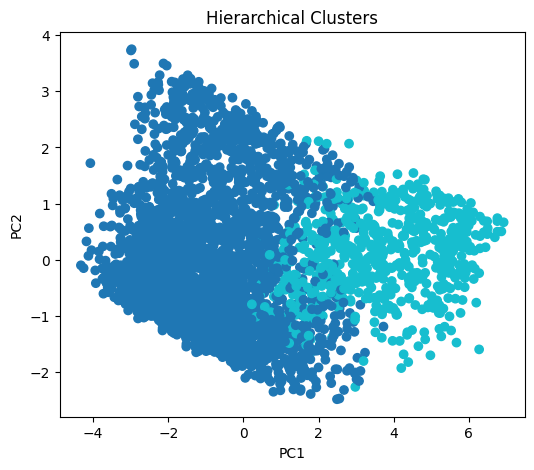

In [68]:
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels_hc, cmap='tab10')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hierarchical Clusters")
plt.show()

In [69]:
pd.crosstab(df_clustered_hc['cluster'], df_clustered_hc['high_risk_flag'], normalize='index')

high_risk_flag,0,1
cluster,,
0,0.873855,0.126145
1,0.475831,0.524169


#### Clustering Evaluation

Adjusting the number of clusters for both clustering methods resulted in 2 clusters yielding the best results. Kmeans clustering had a slightly higher silhouette score than hierarchical but the difference is overall negligible. Both models had significant results when evaluating the target class distributions within each cluster. Each of them had one cluster with a significantly higher true target case proportion than the other. Hierarchical clustering even shows one cluster that is a majority true target cases. This is especially important because the number of true target cases is much lower than the number of false cases. So, a majority distribution of the true cases means there is a strong grouping based on the significant features I chose. This can also be seen in the hierarchical dendogram where there is a natural distinct split into two clusters where the proportions generally match those of the true and false test cases.